In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(".") 
from tqdm import tqdm
import torch
from sklearn.metrics import roc_auc_score
from torchvision.models import ResNet50_Weights
from dataset import *
from torch.utils.data import DataLoader
import pickle

In [2]:
# get transform and create the in-distribution dataset
transform = ResNet50_Weights.IMAGENET1K_V1.transforms()
in_dataset = ImageNet_Format(path='/n/fs/visualai-scr/Data/ILSVRC2012/val/', transform=transform)
in_dataloader = DataLoader(
        in_dataset, batch_size=128, num_workers=8, shuffle=False)

In [3]:
# pre-trained PASS model
model = torch.hub.load('yukimasano/PASS:main', 'moco_resnet50').cuda()
model = model.cuda()
model = model.eval()

Using cache found in /u/wy9086/.cache/torch/hub/yukimasano_PASS_main
/n/fs/wy-project/miniconda3/envs/my-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/n/fs/wy-project/miniconda3/envs/my-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


_IncompatibleKeys(missing_keys=[], unexpected_keys=['fc.0.weight', 'fc.0.bias', 'fc.2.weight', 'fc.2.bias'])


In [4]:
# obtain OOD datasets
out_dataset = ImageNetOOD(imagenet_path='/n/fs/visualai-scr/Data/imagenet21k_resized/imagenet21k_train/', subset_file='imagenetood.txt', transform=transform)
out_y = []
out_dataloader = DataLoader(
        out_dataset, batch_size=128, num_workers=8, shuffle=False)
out_dataset2 = ImageNet_Format(path='/n/fs/visualai-scr/Data/ImageNet-R/imagenet-r', transform=transform)
out_y2 = []
out_dataloader2 = DataLoader(
        out_dataset2, batch_size=128, num_workers=8, shuffle=False)

In [5]:
# extract the pass features
in_features = []
with torch.no_grad():
    for x,y in tqdm(in_dataloader):
        in_features.append(model(x.cuda()).detach().cpu().numpy())
in_features = np.vstack(in_features)
out_features = []
with torch.no_grad():
    for x,y in tqdm(out_dataloader):
        out_features.append(model(x.cuda()).detach().cpu().numpy())
out_features = np.vstack(out_features)
out_features2 = []
with torch.no_grad():
    for x,y in tqdm(out_dataloader2):
        out_features2.append(model(x.cuda()).detach().cpu().numpy())
out_features2 = np.vstack(out_features2)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:41<00:00,  5.69it/s]


In [6]:
# calculate euclidean distance between the in-distribution and out-of-distribution features
in_features = torch.tensor(in_features).cuda()
closest_idx = []
closest_dist = []
with torch.no_grad():
    for i in tqdm(range(out_features.shape[0])):
        distances = torch.cdist(torch.tensor(out_features[i:(i+1),:]).cuda(), in_features)
        minimum, indices = torch.min(distances, dim=1)
        closest_idx.append( indices.item() )
        closest_dist.append( minimum.item() )
# repeat for imagenet-r
closest_idx2 = []
closest_dist2 = []
with torch.no_grad():
    for i in tqdm(range(out_features2.shape[0])):
        distances = torch.cdist(torch.tensor(out_features2[i:(i+1),:]).cuda(), in_features)
        minimum, indices = torch.min(distances, dim=1)
        closest_idx2.append( indices.item() )
        closest_dist2.append( minimum.item() )

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30000/30000 [01:58<00:00, 252.37it/s]


In [7]:
# derive index that sort the distances
reference_idx = np.arange(len(closest_dist))
closest_dist = np.array(closest_dist)
closest_idx = np.array(closest_idx)
idx = np.argsort(closest_dist)
# sort the idx 
closest_dist = closest_dist[idx]
closest_idx = closest_idx[idx]
reference_idx = reference_idx[idx]
# repeat for imagenet-r
reference_idx2 = np.arange(len(closest_dist2))
closest_dist2 = np.array(closest_dist2)
closest_idx2 = np.array(closest_idx2)
idx2 = np.argsort(closest_dist2)
closest_dist2 = closest_dist2[idx2]
closest_idx2 = closest_idx2[idx2]
reference_idx2 = reference_idx2[idx2]

In [8]:
# load the ood scores
with open("imagenetood.pkl", "rb") as f:
    data = pickle.load(f)
    msp_scores = list(data[12]['msp'])
    energy_scores = list(data[12]['energy'])
    vim_scores = list(data[12]['vim'])
    react_scores = list(data[12]['react'])
with open("imagenet1k.pkl", "rb") as f:
    data = pickle.load(f)
    msp_scores2 = list(data[12]['msp'])
    energy_scores2 = list(data[12]['energy'])
    vim_scores2 = list(data[12]['vim'])
    react_scores2 = list(data[12]['react'])
with open("imagenetr.pkl", "rb") as f:
    data = pickle.load(f)
    msp_scores3 = list(data[12]['msp'])
    energy_scores3 = list(data[12]['energy'])
    vim_scores3 = list(data[12]['vim'])
    react_scores3 = list(data[12]['react'])

In [9]:
results = [] # store results
chunks = np.array_split(np.arange(len(vim_scores)), 100) # split into 100 chunks
x = []
y = []
x2 = []
y2 = []
for i in range(len(chunks)):
    ood_scores = np.array(vim_scores)[idx][chunks[i]] # sort the vim scores by distance and take the chunk
    id_scores = vim_scores2
    auroc = roc_auc_score([1]*len(id_scores) + [0]*len(ood_scores), list(id_scores) + list(ood_scores))
    x.append(np.mean(closest_dist[chunks[i]])) # average distance of the chunk
    y.append(auroc) # ood detection performance

# repeat for imagenet-r
chunks = np.array_split(np.arange(len(vim_scores3)), 100) 
for i in range(len(chunks)):
    ood_scores = np.array(vim_scores3)[idx2][chunks[i]]
    id_scores = vim_scores2
    auroc = roc_auc_score([1]*len(id_scores) + [0]*len(ood_scores), list(id_scores) + list(ood_scores))
    x2.append(np.mean(closest_dist2[chunks[i]]))
    y2.append(auroc)
    
results.append((x,y,x2,y2))

# repeat for msp
chunks = np.array_split(np.arange(len(vim_scores)), 100) 
x = []
y = []
x2 = []
y2 = []
for i in tqdm(range(len(chunks))):
    ood_scores = np.array(msp_scores)[idx][chunks[i]]
    id_scores = msp_scores2
    auroc = roc_auc_score([1]*len(id_scores) + [0]*len(ood_scores), list(id_scores) + list(ood_scores))
    x.append(np.mean(closest_dist[chunks[i]]))
    y.append(auroc)
chunks = np.array_split(np.arange(len(vim_scores3)), 100) 
for i in tqdm(range(len(chunks))):
    ood_scores = np.array(msp_scores3)[idx2][chunks[i]]
    id_scores = msp_scores2
    auroc = roc_auc_score([1]*len(id_scores) + [0]*len(ood_scores), list(id_scores) + list(ood_scores))
    x2.append(np.mean(closest_dist2[chunks[i]]))
    y2.append(auroc) 

results.append((x,y,x2,y2))

# repeat for energy
chunks = np.array_split(np.arange(len(vim_scores)), 100) 
x = []
y = []
x2 = []
y2 = []
for i in tqdm(range(len(chunks))):
    ood_scores = np.array(energy_scores)[idx][chunks[i]]
    id_scores = energy_scores2
    auroc = roc_auc_score([1]*len(id_scores) + [0]*len(ood_scores), list(id_scores) + list(ood_scores))
    x.append(np.mean(closest_dist[chunks[i]]))
    y.append(auroc)
chunks = np.array_split(np.arange(len(vim_scores3)), 100) 
for i in tqdm(range(len(chunks))):
    ood_scores = np.array(energy_scores3)[idx2][chunks[i]]
    id_scores = energy_scores2
    auroc = roc_auc_score([1]*len(id_scores) + [0]*len(ood_scores), list(id_scores) + list(ood_scores))
    x2.append(np.mean(closest_dist2[chunks[i]]))
    y2.append(auroc) 
    
results.append((x,y,x2,y2))

# repeat for react
chunks = np.array_split(np.arange(len(vim_scores)), 100) 
x = []
y = []
x2 = []
y2 = []
for i in range(len(chunks)):
    ood_scores = np.array( react_scores)[idx][chunks[i]]
    id_scores = react_scores2
    auroc = roc_auc_score([1]*len(id_scores) + [0]*len(ood_scores), list(id_scores) + list(ood_scores))
    x.append(np.mean(closest_dist[chunks[i]]))
    y.append(auroc)
chunks = np.array_split(np.arange(len(vim_scores3)), 100) 
for i in range(len(chunks)):
    ood_scores = np.array(react_scores3)[idx2][chunks[i]]
    id_scores = react_scores2
    auroc = roc_auc_score([1]*len(id_scores) + [0]*len(ood_scores), list(id_scores) + list(ood_scores))
    x2.append(np.mean(closest_dist2[chunks[i]]))
    y2.append(auroc)

results.append((x,y,x2,y2))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:37<00:00,  2.67it/s]


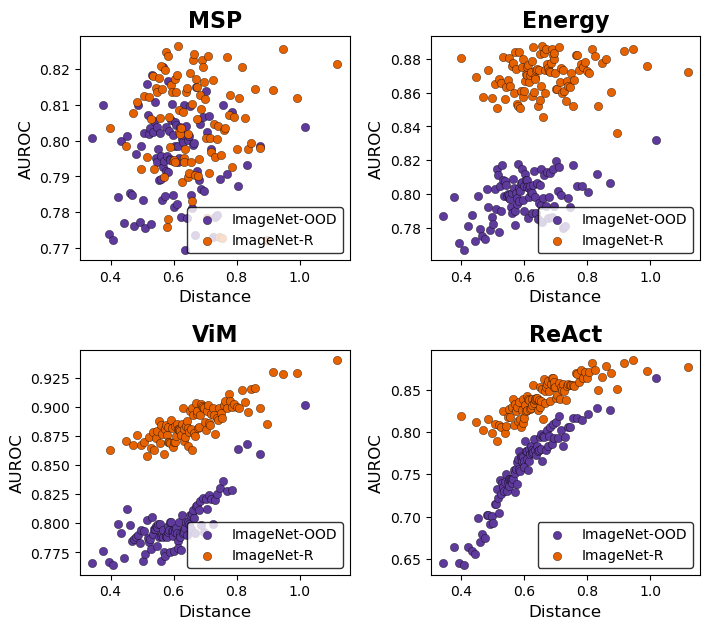

In [10]:
# generate the figure
fig = plt.figure(figsize=(8,7))

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.tight_layout()

plt.subplot(2,2,1)
plt.scatter(results[1][0],results[1][1], label="ImageNet-OOD",edgecolors='black', color='#5D3A9B', lw=0.25)
plt.scatter(results[1][2],results[1][3], label="ImageNet-R",edgecolors='black', color='#E66100', lw=0.25)
plt.title("MSP", fontsize=16,fontweight='bold')
plt.xlabel("Distance", fontsize=12)
plt.ylabel("AUROC", fontsize=12)
plt.legend(loc='lower right', edgecolor='black')

plt.subplot(2,2,2)
plt.scatter(results[2][0],results[2][1], label="ImageNet-OOD",edgecolors='black', color='#5D3A9B', lw=0.25)
plt.scatter(results[2][2],results[2][3], label="ImageNet-R",edgecolors='black', color='#E66100', lw=0.25)
plt.title("Energy", fontsize=16,fontweight='bold')
plt.xlabel("Distance", fontsize=12)
plt.ylabel("AUROC", fontsize=12)
plt.legend(loc='lower right', edgecolor='black')


plt.subplot(2,2,3)
plt.scatter(results[0][0],results[0][1], label="ImageNet-OOD",edgecolors='black', color='#5D3A9B', lw=0.25)
plt.scatter(results[0][2],results[0][3], label="ImageNet-R",edgecolors='black', color='#E66100', lw=0.25)
plt.title("ViM", fontsize=16,fontweight='bold')
plt.xlabel("Distance", fontsize=12)
plt.ylabel("AUROC", fontsize=12)
plt.legend(loc='lower right',edgecolor='black')

plt.subplot(2,2,4)
plt.scatter(results[3][0],results[3][1], label="ImageNet-OOD",edgecolors='black', color='#5D3A9B', lw=0.25)
plt.scatter(results[3][2],results[3][3], label="ImageNet-R",edgecolors='black', color='#E66100', lw=0.25)
plt.title("ReAct", fontsize=16,fontweight='bold')
plt.xlabel("Distance", fontsize=12)
plt.ylabel("AUROC", fontsize=12)
plt.legend(edgecolor='black')